# BIG WIP

In [11]:
!pip install osmnx

  Using cached osmnx-2.1.0-py3-none-any.whl.metadata (4.7 kB)
Using cached osmnx-2.1.0-py3-none-any.whl (104 kB)


In [12]:
import pandas as pd
import geopandas as gpd
import numpy as np
from helper_functions import safe_wkt_load, quick_px_scattermap
import osmnx as ox
import networkx as nx
from sklearn.cluster import DBSCAN
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [13]:
station_avg_delay = pd.read_csv("../data/processed/cleaned_delay_data.csv")
station_avg_ridership = pd.read_csv("../data/processed/selected_station_ridership.csv")
selected_routes_shapes = pd.read_csv("../data/processed/selected_routes.csv")
sj_adt = pd.read_csv("../data/processed/selected_sj_adt.csv")

# Join Avg. Delay and Avg. Ridership Tables

In [14]:
selected_routes = ['22', 'Rapid 522', '23', 'Rapid 523', '25', '60']
station_avg_delay = station_avg_delay[station_avg_delay["route_id"].isin(selected_routes)]
station_avg_delay = station_avg_delay.groupby(['route_id', 'direction_id', 'stop_id', 'stop_sequence']).agg(mean_delay=("computed_delay_sec", "mean")).reset_index().sort_values(['route_id', 'direction_id', 'stop_sequence'])
station_avg_delay["route_id"] = station_avg_delay["route_id"].str.replace(
    r"^Rapid\s+", "", regex=True
).astype(int)
station_avg_delay

,route_id,direction_id,stop_id,stop_sequence,mean_delay
18,22,0,60328,2,-28.103448
19,22,0,60329,3,79.400000
20,22,0,60330,4,56.566667
21,22,0,60331,5,15.366667
22,22,0,60332,6,-25.566667
...,...,...,...,...,...
739,523,1,62264,25,-436.909091
740,523,1,62265,26,-463.590909
741,523,1,62266,27,-484.045455
742,523,1,62267,28,-523.681818


In [15]:
station_avg_ridership['direction_id'] = station_avg_ridership['direction_id'] % 10
station_avg_ridership = station_avg_ridership.sort_values(['route_id', 'direction_id', 'stop_id'])
station_avg_ridership

,route_id,direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.62758 1954225.5200159)
4,22,0,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.00288408 1954992.24617273)
6,22,0,60035,King & Alum Rock,149.607974,157.936236,307.544210,POINT (6167727.93202934 1953654.17929506)
7,22,0,60036,King & San Antonio,36.418456,38.469837,74.888293,POINT (6168552.89461824 1952565.84026439)
8,22,0,60037,King & Hermocilla,31.495157,45.198273,76.693430,POINT (6169311.51383591 1951509.07203673)
...,...,...,...,...,...,...,...,...
586,523,1,64478,Lockheed Martin Transit Center,0.000000,317.466630,317.466630,POINT (6117801.90097608 1975568.38743506)
601,523,1,64696,Stevens Creek & Winchester,85.577443,90.755989,176.333432,POINT (6139677.16759291 1943518.2914304)
620,523,1,65741,Stevens Creek & Valley Fair / Santana Row,109.060532,391.806776,500.867308,POINT (6141126.594156 1943538.09191573)
642,523,1,65902,Sunnyvale-Saratoga & El Camino,189.107898,219.736022,408.843920,POINT (6116423.22131875 1959757.18710214)


In [16]:
stations_df = pd.merge(station_avg_delay, station_avg_ridership, on=['route_id', 'direction_id', 'stop_id'], how='inner')
stations_df["geometry"] = stations_df["geometry"].apply(safe_wkt_load)
stations_gdf = gpd.GeoDataFrame(stations_df, geometry='geometry', crs="EPSG:2227").sort_values(["route_id", "direction_id", "stop_sequence"])
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60328,2,-28.103448,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454)
1,22,0,60329,3,79.400000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972)
2,22,0,60330,4,56.566667,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876)
3,22,0,60331,5,15.366667,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671)
4,22,0,60332,6,-25.566667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848)
...,...,...,...,...,...,...,...,...,...,...
717,523,1,62264,25,-436.909091,Mathilda & Maude,10.363231,41.620255,51.983486,POINT (6117130.545 1968192.871)
718,523,1,62265,26,-463.590909,Mathilda & San Aleso,12.054019,68.420606,80.474624,POINT (6117522.548 1969635.794)
719,523,1,62266,27,-484.045455,Mathilda & Ross,1.095763,59.223451,60.319214,POINT (6118104.047 1971957.972)
720,523,1,62267,28,-523.681818,Mathilda & Moffett Park,0.379121,21.976828,22.355949,POINT (6118481.886 1973928.068)


# Determine Station Spacings

In [30]:
G = ox.graph_from_place("Santa Clara County, California, USA", network_type="drive")
G = ox.project_graph(G, to_crs="EPSG:2227")

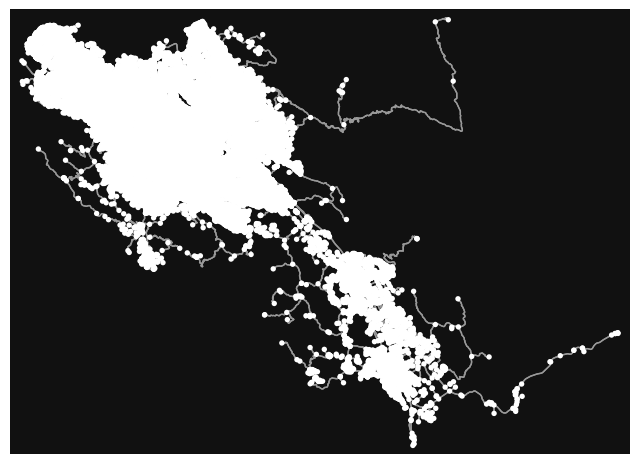

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [31]:
ox.plot_graph(G)

In [32]:
stations_gdf = stations_gdf.to_crs(G.graph["crs"])

nodes = ox.distance.nearest_nodes(
    G,
    X=stations_gdf.geometry.x,
    Y=stations_gdf.geometry.y
)

stations_gdf["node"] = nodes
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node
0,22,0,60328,2,-28.103448,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454),868564168
1,22,0,60329,3,79.400000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538
2,22,0,60330,4,56.566667,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513
3,22,0,60331,5,15.366667,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519
4,22,0,60332,6,-25.566667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560
...,...,...,...,...,...,...,...,...,...,...,...
717,523,1,62264,25,-436.909091,Mathilda & Maude,10.363231,41.620255,51.983486,POINT (6117130.545 1968192.871),65431385
718,523,1,62265,26,-463.590909,Mathilda & San Aleso,12.054019,68.420606,80.474624,POINT (6117522.548 1969635.794),240434078
719,523,1,62266,27,-484.045455,Mathilda & Ross,1.095763,59.223451,60.319214,POINT (6118104.047 1971957.972),240434069
720,523,1,62267,28,-523.681818,Mathilda & Moffett Park,0.379121,21.976828,22.355949,POINT (6118481.886 1973928.068),6594909329


In [33]:
def compute_osm_spacing(stations_gdf):
    results = []

    for (route_id, direction_id), stops in stations_gdf.groupby(["route_id", "direction_id"]):

        stops = stops.sort_values("stop_sequence").copy()
        spacings = [None]

        for i in range(1, len(stops)):
            n1 = stops.iloc[i - 1]["node"]
            n2 = stops.iloc[i]["node"]

            try:
                dist = nx.shortest_path_length(G, n1, n2, weight="length")
            except:
                dist = None

            spacings.append(dist)

        stops["spacing_ft"] = spacings
        results.append(stops)

    return pd.concat(results, ignore_index=True)

In [34]:
station_spacings = compute_osm_spacing(stations_gdf).dropna()
station_spacings

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node,spacing_ft
1,22,0,60329,3,79.400000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538,697.200342
2,22,0,60330,4,56.566667,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513,352.118584
3,22,0,60331,5,15.366667,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519,372.144171
4,22,0,60332,6,-25.566667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560,309.088220
5,22,0,60333,7,-63.566667,El Camino & Serra,14.807891,3.132274,17.940164,POINT (6082149.768 1983118.266),6067063479,380.384955
...,...,...,...,...,...,...,...,...,...,...,...,...
717,523,1,62264,25,-436.909091,Mathilda & Maude,10.363231,41.620255,51.983486,POINT (6117130.545 1968192.871),65431385,880.271410
718,523,1,62265,26,-463.590909,Mathilda & San Aleso,12.054019,68.420606,80.474624,POINT (6117522.548 1969635.794),240434078,496.158685
719,523,1,62266,27,-484.045455,Mathilda & Ross,1.095763,59.223451,60.319214,POINT (6118104.047 1971957.972),240434069,704.619713
720,523,1,62267,28,-523.681818,Mathilda & Moffett Park,0.379121,21.976828,22.355949,POINT (6118481.886 1973928.068),6594909329,790.720435


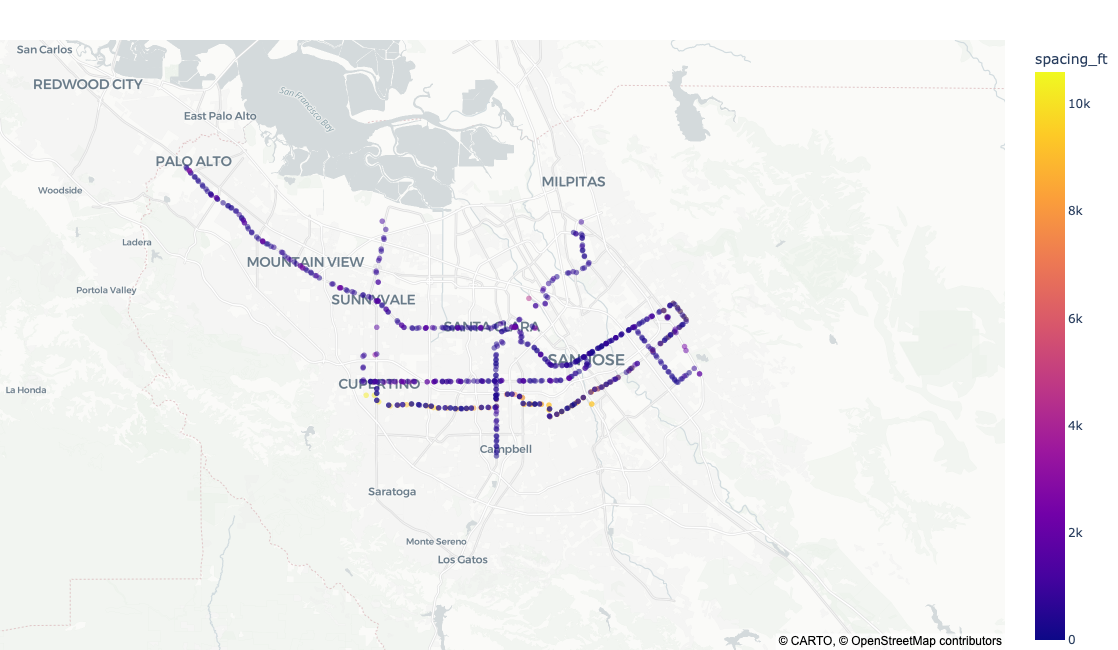

In [38]:
fig = quick_px_scattermap(station_spacings,
                          color="spacing_ft",
                          opacity=0.5,
                          hover_data=["route_id", "direction_id", "stop_sequence", "spacing_ft", "total_b_a"],
                          zoom=10,
                          height=650
)
fig.show()
fig.write_html("../visualizations/map_stop_spacing.html")

# Approximate Nearby ADT for Stations where Data is Available

In [39]:
from shapely import wkt

def safe_wkt_load(x):
    try:
        if isinstance(x, str):
            return wkt.loads(x)
        return x
    except Exception:
        return None

In [40]:
sj_adt["geometry"] = sj_adt["geometry"].apply(safe_wkt_load)
sj_adt_gdf = gpd.GeoDataFrame(sj_adt, geometry='geometry', crs="EPSG:2227")
sj_adt_gdf

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry,index_right,line_id,route_id,route_desc,category,route_length,object_id
0,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
1,4457,8385.0,ALMADEN AVE,N of,WILLOW ST,ALMADEN AVE & WILLOW ST,POINT (6159716.967 1941603.893),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2,4469,848.0,BLEWETT AVE,S of,WILLOW ST,BLEWETT AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
3,4470,936.0,BLEWETTE AVE,S of,WILLOW ST,BLEWETTE AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
4,4474,45690.0,BROKAW RD,E of,OAKLAND RD,BROKAW RD&OAKLAND RD,POINT (6156171.62 1964851.784),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,7251,13221.0,KING RD,S of,OCALA AVE,KING RD & OCALA AVE,POINT (6173723.992 1945717.512),2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3
490,7261,18169.0,STORY RD,E of,BAL HARBOR WAY,STORY RD & BAL HARBOR WAY,POINT (6172131.01 1949785.076),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
491,7262,20206.0,STORY RD,E of,JACKSON AVE,STORY RD & JACKSON AVE,POINT (6174397.292 1951653.894),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
492,7263,21056.0,STORY RD,W of,ROBERTS AVE,STORY RD & ROBERTS AVE,POINT (6166346.746 1945014.702),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5


In [41]:
coords = np.array(list(zip(sj_adt_gdf.geometry.x, sj_adt_gdf.geometry.y)))

# determine clusters of nearby ADT counters and clustering radius (feet)
clustering = DBSCAN(eps=350, min_samples=1).fit(coords)
sj_adt_gdf["cluster"] = clustering.labels_

#determine average adt of vehicles around an intersection
#this roughly handles both traffic on the roadway with the bus stop as well as cross traffic
#because some bus stops are before the intersection and some are after, it can be a bit 
#complicated to determine which ADT counters are most representative for each bus stop
#also because the nearest ADT counter may be on a cross street
adt_clustered = sj_adt_gdf.groupby("cluster").agg({
    "adt": "mean",
    "geometry": "first"
}).reset_index()

#determine the centroid of each cluster, which should roughly center on an intersection
adt_clustered = sj_adt_gdf.dissolve(by="cluster", aggfunc={"adt": "mean"})
adt_clustered["geometry"] = adt_clustered.geometry.centroid
adt_clustered = adt_clustered.reset_index()
adt_clustered

,cluster,geometry,adt
0,0,POINT (6148939.759 1958001.956),14432.000000
1,1,POINT (6159716.967 1941603.893),8385.000000
2,2,POINT (6154826.858 1938135.831),2602.500000
3,3,POINT (6156187.39 1964850.314),42373.500000
4,4,POINT (6154785.569 1964731.863),49988.000000
...,...,...,...
148,148,POINT (6148129.159 1938742.522),10586.000000
149,149,POINT (6159346.467 1948109.352),6374.333333
150,150,POINT (6168046.046 1953273.078),13108.000000
151,151,POINT (6170803.605 1949575.435),31857.500000


In [42]:
sj_station_adt = gpd.sjoin_nearest(station_spacings.copy(), adt_clustered, how="left", max_distance=350, distance_col="dist_to_adt").dropna()
sj_station_adt

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node,spacing_ft,index_right,cluster,adt,dist_to_adt
61,22,0,60397,63,-35.620690,The Alameda & Newhall,39.263776,15.974944,55.238721,POINT (6146329.01 1950686.114),65539401,451.467693,126.0,126.0,15507.000000,154.200181
62,22,0,60398,64,-61.724138,The Alameda & McKendrie,14.479637,9.542598,24.022235,POINT (6147715.539 1949942.149),65488026,444.149090,78.0,78.0,23472.000000,348.137213
64,22,0,60400,66,-85.517241,The Alameda & Naglee,160.791839,129.707882,290.499721,POINT (6148984.787 1948553.677),65539392,334.019610,86.0,86.0,21743.333333,83.786080
66,22,0,60402,68,-103.310345,The Alameda & Hester,9.997135,9.605140,19.602275,POINT (6150347.347 1947097.217),3678132176,262.724721,127.0,127.0,23240.000000,349.140672
67,22,0,60403,69,-131.321429,The Alameda & Hanchett,120.079722,68.305332,188.385054,POINT (6150818.969 1946595.946),3678132173,193.345821,127.0,127.0,23240.000000,342.564864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,523,0,62943,29,-413.625000,7th & Santa Clara,143.234515,177.938383,321.172898,POINT (6159407.567 1948678.317),65468916,108.496893,77.0,77.0,14389.000000,333.345811
699,523,1,60624,6,-108.291667,San Carlos & Barack Obama Blvd,110.744426,49.200355,159.944781,POINT (6154555.783 1943820.343),580402370,2359.121700,10.0,10.0,15538.500000,92.159378
700,523,1,66001,7,-107.500000,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861),281447614,1229.115171,57.0,57.0,19511.250000,124.825786
701,523,1,60634,8,-92.375000,San Carlos & Bascom,105.850666,128.127610,233.978276,POINT (6145412.952 1943448.511),1948671947,1682.062609,64.0,64.0,20418.000000,294.430588


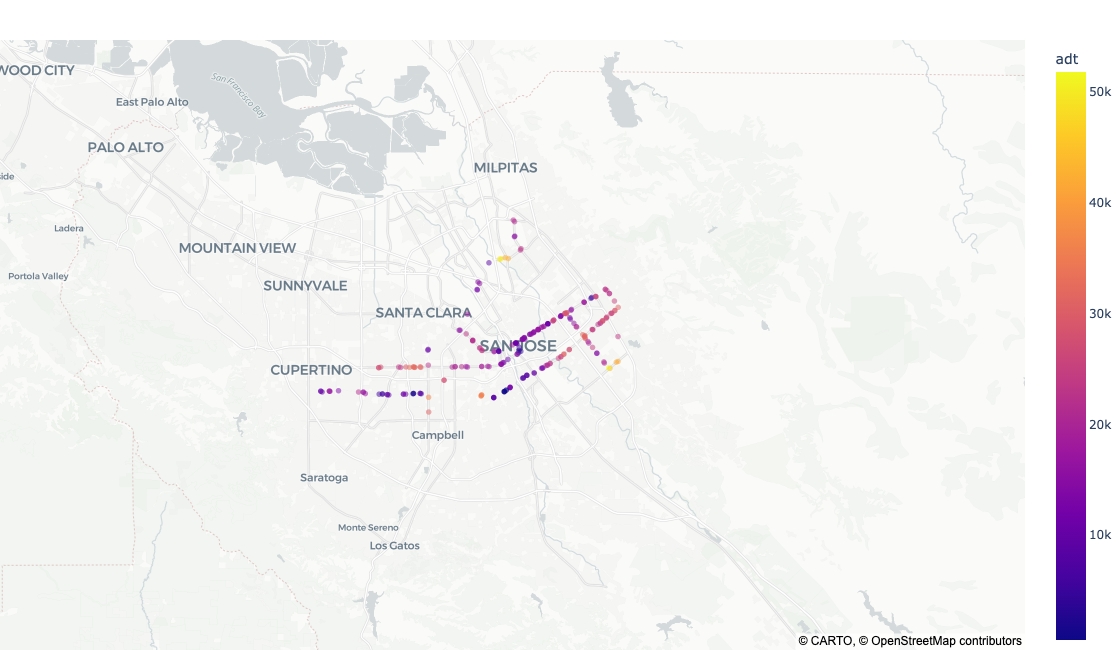

In [43]:
fig = quick_px_scattermap(sj_station_adt,
                          color="adt",
                          opacity=0.5,
                          hover_data=["route_id", "direction_id", "stop_sequence", "spacing_ft", "total_b_a", "adt"],
                          zoom=10,
                          height=650
)
fig.show()

# Regression Models

In [44]:
#model 1: boardings and stop spacings for all selected routes
ind_vars = [
    'boardings', 
    'spacing_ft'   
]

X = station_spacings[ind_vars].copy()
Y = station_spacings['mean_delay']

#scale independent variables
X[ind_vars] = StandardScaler().fit_transform(X[ind_vars])

# Add a constant to the independent variables
X = sm.add_constant(X)
# Fit the linear regression model
model_boardings_spacings = sm.OLS(Y, X).fit()

print(model_boardings_spacings.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_delay   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     8.162
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000313
Time:                        23:33:09   Log-Likelihood:                -4594.3
No. Observations:                 710   AIC:                             9195.
Df Residuals:                     707   BIC:                             9208.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -28.1069      5.879     -4.781      0.0

In [45]:
#model 2: boardings, stop spacings, ADT for stations where data is available (City of San Jose only)
ind_vars = [
    'boardings', 
    'spacing_ft',
    'adt'
]

X = sj_station_adt[ind_vars].copy()
Y = sj_station_adt['mean_delay']

#scale independent variables
X[ind_vars] = StandardScaler().fit_transform(X[ind_vars])

# Add a constant to the independent variables
X = sm.add_constant(X)
# Fit the linear regression model
model_boardings_spacings_adt = sm.OLS(Y, X).fit()

print(model_boardings_spacings_adt.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_delay   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     5.052
Date:                Mon, 11 May 2026   Prob (F-statistic):            0.00205
Time:                        23:33:22   Log-Likelihood:                -1646.4
No. Observations:                 255   AIC:                             3301.
Df Residuals:                     251   BIC:                             3315.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7865      9.725      0.081      0.9

Boardings appears to be the most significant factor in both models, with an inverse correlation, which is interesting. Less boardings, more delay? Spacings make intuitive sense, even if its considerably less significant. Smaller stop spacings, more stops, so more delay. Finally, ADT also makes intuitive sense, as more traffic results in more delay.

# Robustness check: Spearman & Pearson correlations

Per instructor feedback, we report **rank-based (Spearman) and linear (Pearson) correlations** alongside the OLS regression. Spearman is robust to skewed boardings distributions and the long tail of stop spacings on Route 25.

We exclude `spacing_ft == 0` rows (consecutive stops mapped to the same OSM node, ~25 cases) and `boardings == 0` rows; otherwise the full station sample is used.

In [46]:
from scipy import stats

def corr_table(df, y_col, x_cols, label):
    rows = []
    for x in x_cols:
        sub = df[[x, y_col]].dropna()
        sub = sub[sub[x] > 0]
        pr, pp = stats.pearsonr(sub[x], sub[y_col])
        sr, sp = stats.spearmanr(sub[x], sub[y_col])
        rows.append({
            'pair': f'{x} vs. {y_col}',
            'n': len(sub),
            'pearson_r': round(pr, 3),
            'pearson_p': f'{pp:.2e}',
            'spearman_rho': round(sr, 3),
            'spearman_p': f'{sp:.2e}',
        })
    out = pd.DataFrame(rows)
    print(f'--- {label} ---')
    print(out.to_string(index=False))
    print()
    return out

corr_all = corr_table(
    station_spacings,
    y_col='mean_delay',
    x_cols=['boardings', 'spacing_ft'],
    label='Model 1 sample (all selected routes)'
)

corr_sj = corr_table(
    sj_station_adt,
    y_col='mean_delay',
    x_cols=['boardings', 'spacing_ft', 'adt'],
    label='Model 2 sample (San Jose stops with ADT)'
)

--- Model 1 sample (all selected routes) ---
                     pair   n  pearson_r pearson_p  spearman_rho spearman_p
 boardings vs. mean_delay 707     -0.142  1.47e-04        -0.148   8.20e-05
spacing_ft vs. mean_delay 685     -0.021  5.75e-01        -0.216   1.20e-08

--- Model 2 sample (San Jose stops with ADT) ---
                     pair   n  pearson_r pearson_p  spearman_rho spearman_p
 boardings vs. mean_delay 255     -0.180  3.93e-03        -0.115   6.69e-02
spacing_ft vs. mean_delay 246     -0.076  2.36e-01        -0.233   2.26e-04
       adt vs. mean_delay 255      0.120  5.58e-02         0.173   5.62e-03



**Reading the table:**

- `spacing_ft`: Pearson r is near zero, but Spearman ρ ≈ -0.22 (p ≪ 0.001). The Spearman result indicates a **robust monotonic** association — closer stops are paired with longer delays — that the linear Pearson statistic misses because of long-tail outliers on Route 25 segments crossing freeway gaps.
- `boardings`: weak but consistent negative association in both Pearson and Spearman. The unexpected sign likely reflects that high-ridership stops sit on Rapid 522/523 corridors, which run looser timetables and therefore tend to arrive ahead of schedule.
- `adt`: positive association in the San Jose subsample (more traffic → more delay), consistent with intuition.

We treat all three as **descriptive associations**, not causal effects, given the day-specific RT-data sample and the imperfect schedule-to-observation matching documented in Section 3.